In [2]:
import torch
from torch import nn
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import random
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    cohen_kappa_score,
    matthews_corrcoef,
    log_loss,
)
from torch.utils.data import Dataset, DataLoader
import os
import seaborn as sns
from tqdm import tqdm
import pandas as pd
from collections import Counter
from tqdm.auto import tqdm
from tabulate import tabulate
from typing import Dict, List

%matplotlib inline

In [3]:
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
train_a = pd.read_csv("/kaggle/input/datasets/organizations/BengaliAI/numta/training-a.csv")
train_b = pd.read_csv("/kaggle/input/datasets/organizations/BengaliAI/numta/training-b.csv")
train_c = pd.read_csv("/kaggle/input/datasets/organizations/BengaliAI/numta/training-c.csv")
train_d = pd.read_csv("/kaggle/input/datasets/organizations/BengaliAI/numta/training-d.csv")
train_e = pd.read_csv("/kaggle/input/datasets/organizations/BengaliAI/numta/training-e.csv")
train = pd.concat([train_a, train_b, train_c, train_d, train_e], ignore_index=True)
train.head()

,filename,original filename,scanid,digit,database name original,contributing team,database name,num,districtid,institutionid,gender,age,datestamp
0,a00000.png,Scan_58_digit_5_num_8.png,58,5,BHDDB,Buet_Broncos,training-a,NaN,NaN,NaN,NaN,NaN,NaN
1,a00001.png,Scan_73_digit_3_num_5.png,73,3,BHDDB,Buet_Broncos,training-a,NaN,NaN,NaN,NaN,NaN,NaN
2,a00002.png,Scan_18_digit_1_num_3.png,18,1,BHDDB,Buet_Broncos,training-a,NaN,NaN,NaN,NaN,NaN,NaN
3,a00003.png,Scan_166_digit_7_num_3.png,166,7,BHDDB,Buet_Broncos,training-a,NaN,NaN,NaN,NaN,NaN,NaN
4,a00004.png,Scan_108_digit_0_num_1.png,108,0,BHDDB,Buet_Broncos,training-a,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
train=train[["filename","digit"]]
train.head()

,filename,digit
0,a00000.png,5
1,a00001.png,3
2,a00002.png,1
3,a00003.png,7
4,a00004.png,0


In [6]:
train.isnull().sum()

filename    0
digit       0
dtype: int64

In [7]:
train.shape

(72045, 2)

**dataset class length**

In [8]:
train["digit"].value_counts()

digit
4    7252
0    7241
5    7239
3    7233
2    7224
6    7212
1    7194
7    7179
8    7158
9    7113
Name: count, dtype: int64

/tmp/ipykernel_57/643012292.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train,x="digit",palette="gnuplot")


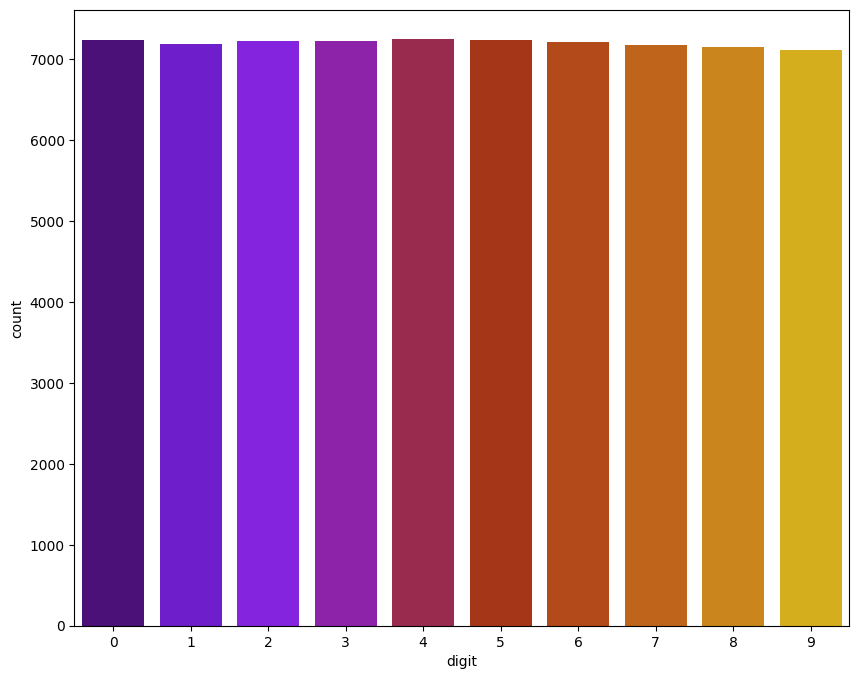

In [9]:
plt.figure(figsize=(10,8))
sns.countplot(data=train,x="digit",palette="gnuplot")
plt.show()

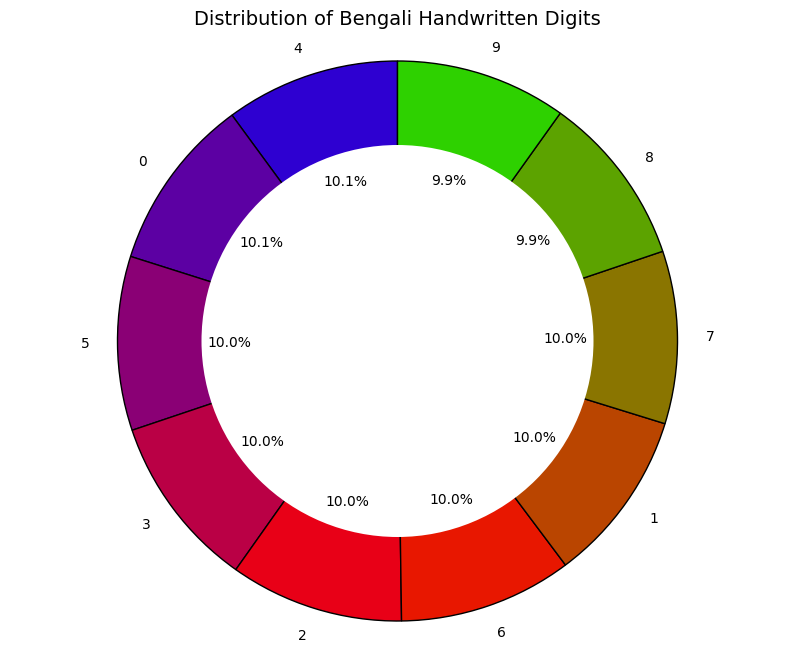

In [10]:
digit_counts = train['digit'].value_counts()

plt.figure(figsize=(10, 8))
colors = sns.color_palette("brg", len(digit_counts))
plt.pie(digit_counts, labels=digit_counts.index, autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops={'edgecolor': 'black'})

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)
plt.axis("equal")
plt.title("Distribution of Bengali Handwritten Digits", fontsize=14)
plt.show()

# Visualize images from train data

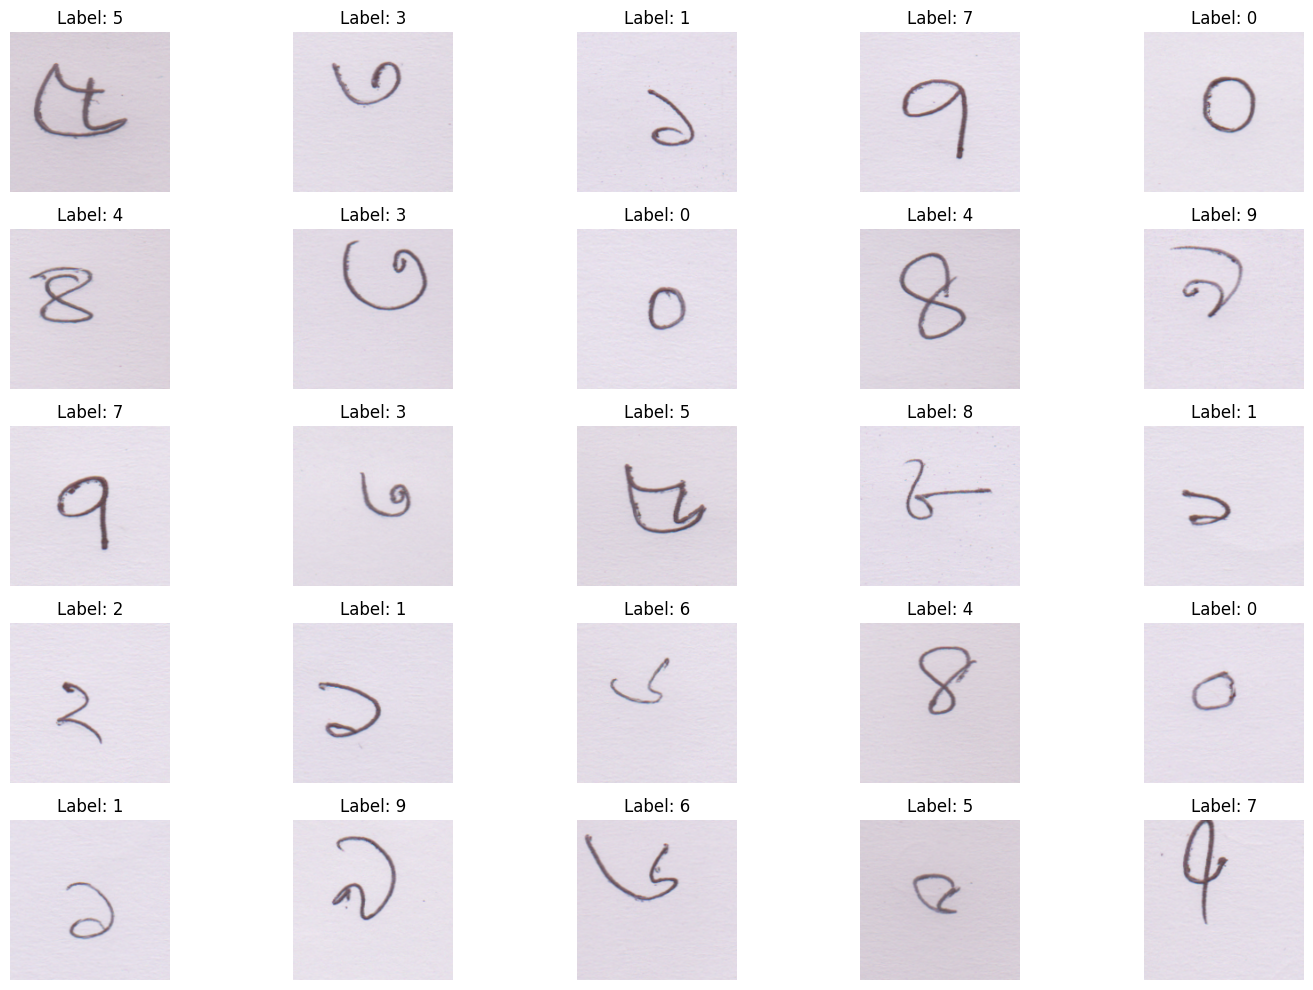

In [11]:
image_train_a="/kaggle/input/datasets/organizations/BengaliAI/numta/training-a/"
image_train_b="/kaggle/input/datasets/organizations/BengaliAI/numta/training-b/"
image_train_c="/kaggle/input/datasets/organizations/BengaliAI/numta/training-c/"
image_train_d="/kaggle/input/datasets/organizations/BengaliAI/numta/training-d/"
image_train_e="/kaggle/input/datasets/organizations/BengaliAI/numta/training-e/"
image_train_paths=[image_train_a,image_train_b,image_train_c,image_train_d,image_train_e]

fig, axes = plt.subplots(5, 5, figsize=(15, 10))

for i, ax in enumerate(axes.flat):
    if i < len(train):
        filename = train.iloc[i]["filename"]
        label = train.iloc[i]["digit"]

        img_path = None
        for folder in image_train_paths:
            path = os.path.join(folder, filename)
            if os.path.exists(path):
                img_path = path
                break

        if img_path:
            img = Image.open(img_path)
            ax.imshow(img, cmap="gray")
            ax.set_title(f"Label: {label}")
        else:
            ax.set_title("Not Found")

    ax.axis("off")

plt.tight_layout()
plt.show()


In [12]:
image_data = []

for i, row in tqdm(train.iterrows(), total=len(train), desc="Processing Images"):
    filename = row["filename"]
    label = row["digit"]

    img_path = None
    for folder in image_train_paths:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            img_path = path
            break

    if img_path:
        img = Image.open(img_path)
        image_data.append({"image": img, "label": label})

df_images = pd.DataFrame(image_data)

Processing Images:   0%|          | 0/72045 [00:00<?, ?it/s]

In [13]:
df_images.head()

,image,label
0,<PIL.PngImagePlugin.PngImageFile image mode=RG...,5
1,<PIL.PngImagePlugin.PngImageFile image mode=RG...,3
2,<PIL.PngImagePlugin.PngImageFile image mode=RG...,1
3,<PIL.PngImagePlugin.PngImageFile image mode=RG...,7
4,<PIL.PngImagePlugin.PngImageFile image mode=RG...,0


**Test Data**

In [14]:
test_a = "/kaggle/input/datasets/organizations/BengaliAI/numta/testing-a/"
test_b = "/kaggle/input/datasets/organizations/BengaliAI/numta/testing-b/"
test_c = "/kaggle/input/datasets/organizations/BengaliAI/numta/testing-c/"
test_d = "/kaggle/input/datasets/organizations/BengaliAI/numta/testing-d/"
test_e = "/kaggle/input/datasets/organizations/BengaliAI/numta/testing-e/"
test_a_images = [os.path.join(test_a, f) for f in os.listdir(test_a) if f.endswith('.png') or f.endswith('.jpg') or f.endswith('.jpeg')]
test_b_images = [os.path.join(test_b, f) for f in os.listdir(test_b) if f.endswith('.png') or f.endswith('.jpg') or f.endswith('.jpeg')]
test_c_images = [os.path.join(test_c, f) for f in os.listdir(test_c) if f.endswith('.png') or f.endswith('.jpg') or f.endswith('.jpeg')]
test_d_images = [os.path.join(test_d, f) for f in os.listdir(test_d) if f.endswith('.png') or f.endswith('.jpg') or f.endswith('.jpeg')]
test_e_images = [os.path.join(test_e, f) for f in os.listdir(test_e) if f.endswith('.png') or f.endswith('.jpg') or f.endswith('.jpeg')]
all_images = test_a_images + test_b_images + test_c_images + test_d_images + test_e_images
test= pd.DataFrame(all_images, columns=['imagefile'])
test.head()

,imagefile
0,/kaggle/input/datasets/organizations/BengaliAI...
1,/kaggle/input/datasets/organizations/BengaliAI...
2,/kaggle/input/datasets/organizations/BengaliAI...
3,/kaggle/input/datasets/organizations/BengaliAI...
4,/kaggle/input/datasets/organizations/BengaliAI...


In [15]:
test.shape

(12857, 1)

In [16]:
test.isnull().sum()

imagefile    0
dtype: int64

# visualize images from test data

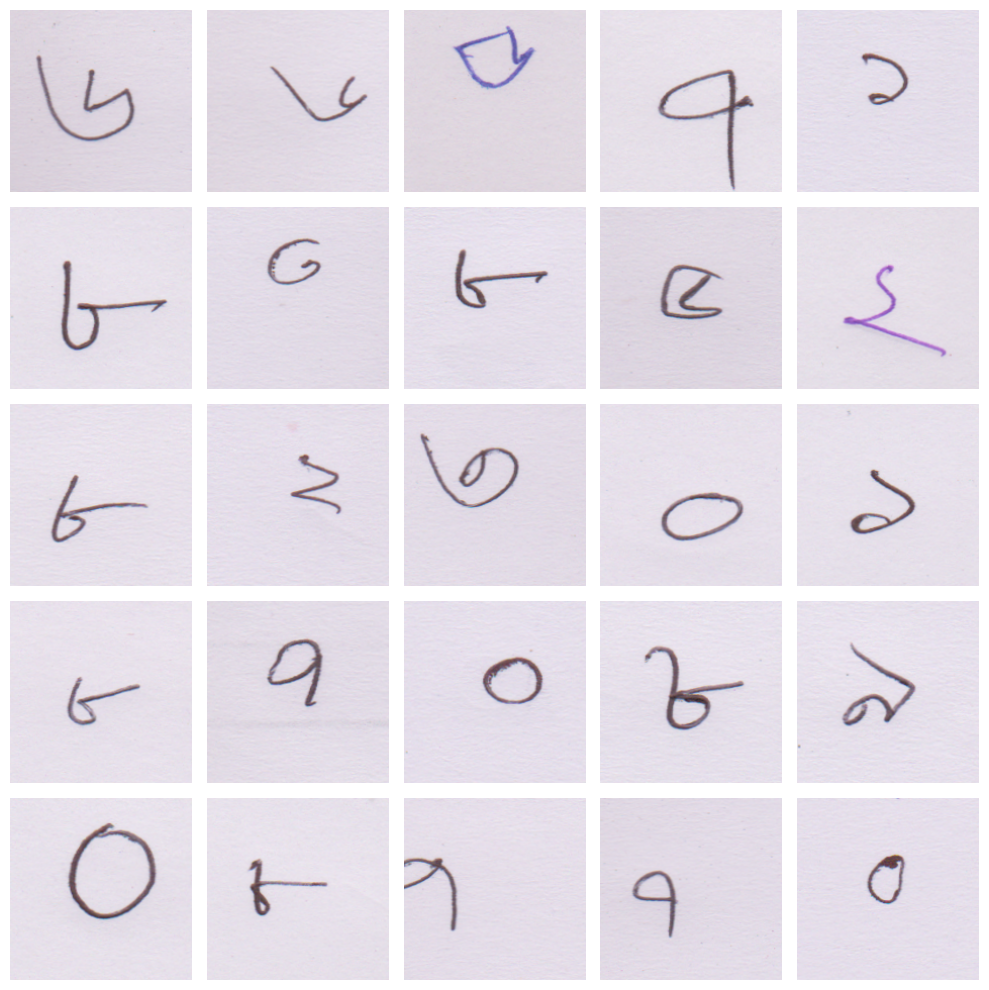

In [17]:
fig, axes = plt.subplots(5, 5, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    if i < len(test):
        img_path = test.iloc[i]["imagefile"]
        img = Image.open(img_path)
        ax.imshow(img, cmap="gray")
    
    ax.axis("off")

plt.tight_layout()
plt.show()

# transform Images

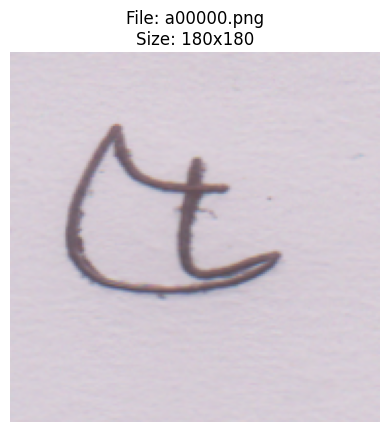

In [18]:
test_image = df_images["image"][0]
file_name = train.iloc[0]["filename"]  # Access the filename from the original DataFrame
image_size = test_image.size  # Get the image size (width, height)

plt.imshow(test_image)
plt.title(f"File: {file_name}\nSize: {image_size[0]}x{image_size[1]}")
plt.axis('off')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6451751..2.3088455].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.79929787..2.2565577].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.004795..2.64].


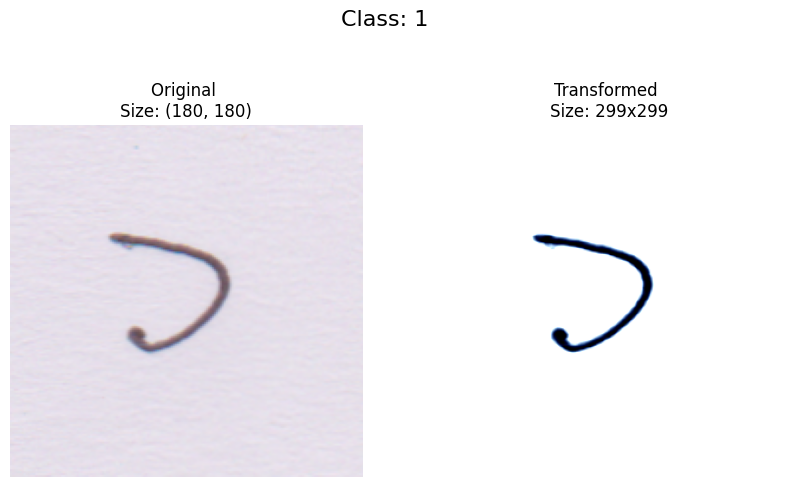

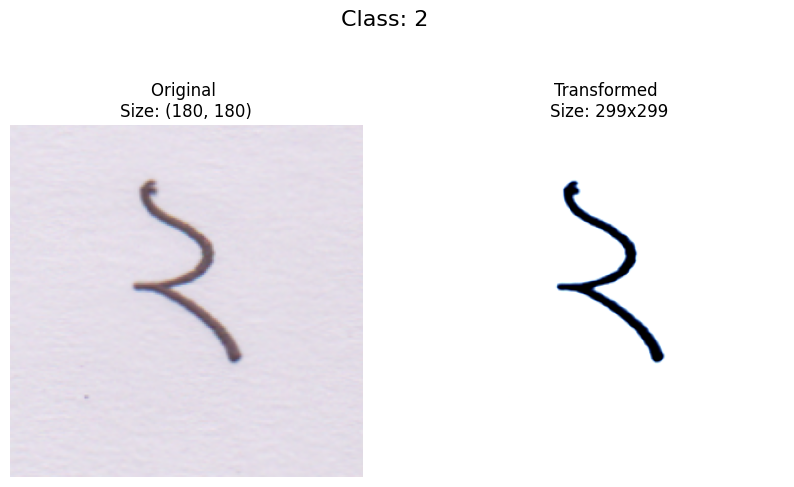

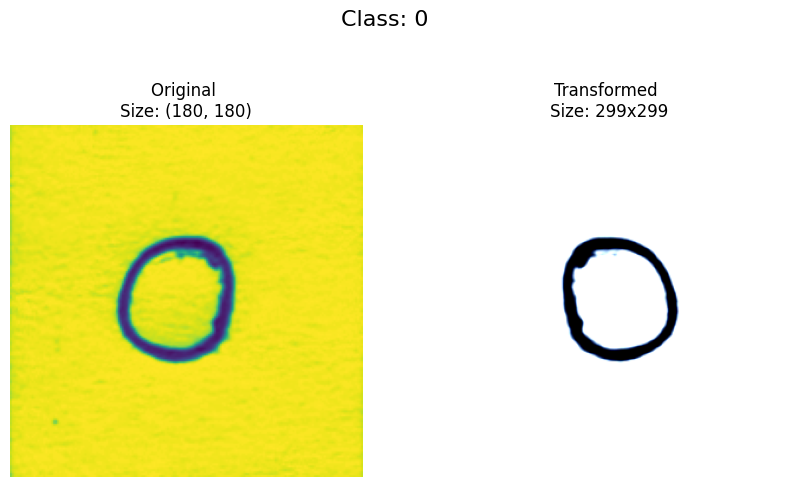

In [19]:
data_transform = transforms.Compose([
    transforms.Resize(size=(299, 299)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def plot_transformed_images_from_df(df_images, transform, n=3, seed=42):
    random.seed(seed)
    random_images = random.sample(range(len(df_images)), k=n)
    
    for idx in random_images:
        image = df_images.iloc[idx]["image"]
        label = df_images.iloc[idx]["label"]

        fig, ax = plt.subplots(1, 2, figsize=(10, 6))
        
        # Original image
        ax[0].imshow(image)
        ax[0].set_title(f"Original \nSize: {image.size}")
        ax[0].axis("off")

        # Transformed image
        transformed_image = transform(image).permute(1, 2, 0)
        ax[1].imshow(transformed_image)
        ax[1].set_title(f"Transformed \nSize: {transformed_image.shape[1]}x{transformed_image.shape[0]}")
        ax[1].axis("off")

        fig.suptitle(f"Class: {label}", fontsize=16)


plot_transformed_images_from_df(df_images, transform=data_transform, n=3)

# split the dataset

In [20]:
from sklearn.model_selection import train_test_split


train_df, valid_df = train_test_split(df_images, test_size=0.2, random_state=42)

# Display the number of samples in each set
print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(valid_df)}")

Training set size: 57636
Validation set size: 14409


In [21]:
class ImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image = self.dataframe.iloc[idx]["image"]
        label = self.dataframe.iloc[idx]["label"]
        
        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label,dtype=torch.long)

train_dataset = ImageDataset(dataframe=train_df, transform=data_transform)
valid_dataset = ImageDataset(dataframe=valid_df, transform=data_transform)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,drop_last=True)
valid_loader = DataLoader(valid_dataset, batch_size=16, shuffle=False,drop_last=True)

In [22]:
for images, labels in train_loader:
    print(f"Batch images shape: {images.shape}")
    print(f"Batch labels: {labels}")
    break

Batch images shape: torch.Size([16, 3, 299, 299])
Batch labels: tensor([3, 3, 8, 2, 1, 8, 3, 4, 8, 8, 7, 5, 6, 0, 5, 1])


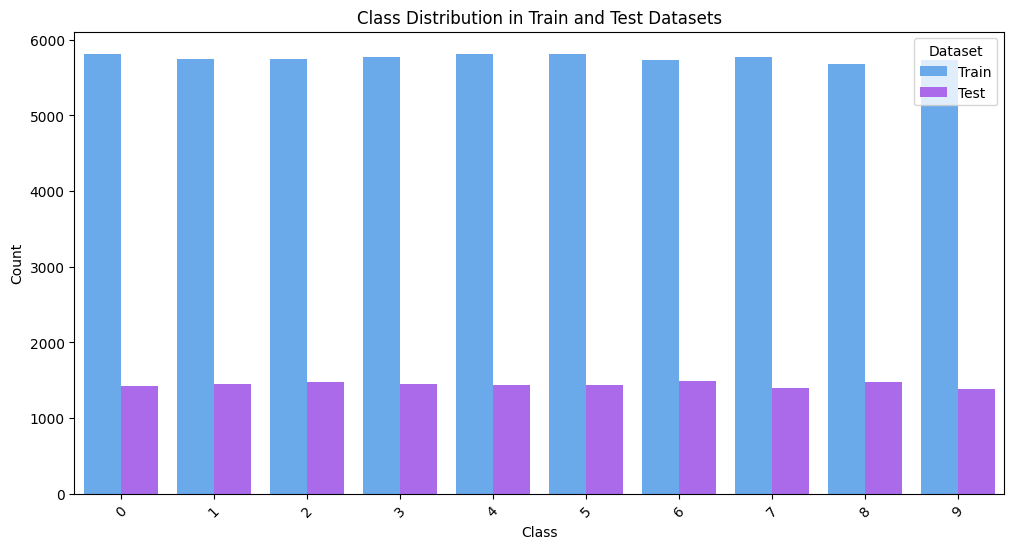

In [23]:
def get_labels(dataloader):
    labels = []
    for _, label in dataloader:
        labels.extend(label.numpy())
    return labels

train_labels = get_labels(train_loader)
test_labels = get_labels(valid_loader)

train_class_counts = Counter(train_labels)
test_class_counts = Counter(test_labels)

train_df = pd.DataFrame(train_class_counts.items(), columns=['Class', 'Count'])
test_df = pd.DataFrame(test_class_counts.items(), columns=['Class', 'Count'])

train_df['Dataset'] = 'Train'
test_df['Dataset'] = 'Test'

combined_df = pd.concat([train_df, test_df])

plt.figure(figsize=(12, 6))
sns.barplot(data=combined_df, x='Class', y='Count', hue='Dataset', palette='cool')
plt.title('Class Distribution in Train and Test Datasets')
plt.xlabel('Class')
plt.ylabel('Count')
plt.legend(title='Dataset')
plt.xticks(rotation=45)
plt.show()

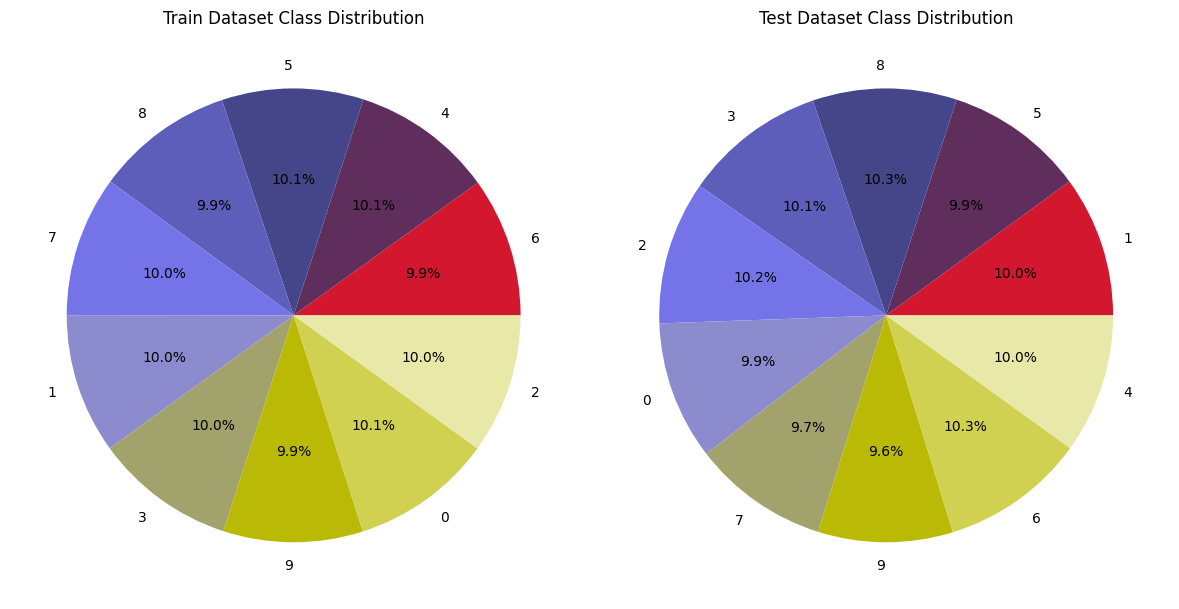

In [24]:
train_labels = get_labels(train_loader)
test_labels = get_labels(valid_loader)

train_class_counts = Counter(train_labels)
test_class_counts = Counter(test_labels)

train_df = pd.DataFrame(train_class_counts.items(), columns=['Class', 'Count'])
test_df = pd.DataFrame(test_class_counts.items(), columns=['Class', 'Count'])

train_df['Dataset'] = 'Train'
test_df['Dataset'] = 'Test'

combined_df = pd.concat([train_df, test_df])

# Plotting Pie Charts
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
colors = sns.color_palette("gist_stern", len(digit_counts))
axes[0].pie(train_df['Count'], labels=train_df['Class'], autopct='%1.1f%%', colors=colors)
axes[0].set_title('Train Dataset Class Distribution')

axes[1].pie(test_df['Count'], labels=test_df['Class'], autopct='%1.1f%%', colors=colors)
axes[1].set_title('Test Dataset Class Distribution')

plt.tight_layout()
plt.show()


**Create Model**

**Model Description**
Inception v3: Based on the exploration of ways to scale up networks in ways that aim at utilizing the added computation as efficiently as possible by suitably factorized convolutions and aggressive regularization. We benchmark our methods on the ILSVRC 2012 classification challenge validation set demonstrate substantial gains over the state of the art: 21.2% top-1 and 5.6% top-5 error for single frame evaluation using a network with a computational cost of 5 billion multiply-adds per inference and with using less than 25 million parameters. With an ensemble of 4 models and multi-crop evaluation, we report 3.5% top-5 error on the validation set (3.6% error on the test set) and 17.3% top-1 error on the validation set.

In [25]:


model = torch.hub.load('pytorch/vision:v0.10.0', 'inception_v3', pretrained=True)
n_classes = len(train_df['Class'].unique())
model.fc = nn.Linear(model.fc.in_features, n_classes)
model = model.to(device)
from torchinfo import summary
summary(model, input_size=[16, 3,299,299])

Downloading: "https://github.com/pytorch/vision/zipball/v0.10.0" to /root/.cache/torch/hub/v0.10.0.zip


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 210MB/s] 


Layer (type:depth-idx)                   Output Shape              Param #
Inception3                               [16, 10]                  3,326,696
├─BasicConv2d: 1-1                       [16, 32, 149, 149]        --
│    └─Conv2d: 2-1                       [16, 32, 149, 149]        864
│    └─BatchNorm2d: 2-2                  [16, 32, 149, 149]        64
├─BasicConv2d: 1-2                       [16, 32, 147, 147]        --
│    └─Conv2d: 2-3                       [16, 32, 147, 147]        9,216
│    └─BatchNorm2d: 2-4                  [16, 32, 147, 147]        64
├─BasicConv2d: 1-3                       [16, 64, 147, 147]        --
│    └─Conv2d: 2-5                       [16, 64, 147, 147]        18,432
│    └─BatchNorm2d: 2-6                  [16, 64, 147, 147]        128
├─MaxPool2d: 1-4                         [16, 64, 73, 73]          --
├─BasicConv2d: 1-5                       [16, 80, 73, 73]          --
│    └─Conv2d: 2-7                       [16, 80, 73, 73]          5,

**Create train & test loop functions**

In [26]:


def train_step(model, dataloader, loss_fn, optimizer, device):
    model.train()
    train_loss, train_acc = 0, 0
    pbar = tqdm(dataloader, desc="Train")
    for X, y in pbar:
        X, y = X.to(device), y.to(device)
        output = model(X)
        y_pred = output.logits if hasattr(output, "logits") else output
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        y_pred_class = torch.argmax(y_pred, dim=1)
        train_acc += (y_pred_class == y).sum().item() / y.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    return train_loss / len(dataloader), train_acc / len(dataloader)



In [27]:

def valid_step(model, dataloader, loss_fn, device):
    model.eval()
    test_loss, test_acc = 0, 0
    with torch.inference_mode():
        pbar = tqdm(dataloader, desc="Valid")
        for X, y in pbar:
            X, y = X.to(device), y.to(device)
            output = model(X)
            test_pred_logits = output.logits if hasattr(output, "logits") else output
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item() / y.size(0))
            pbar.set_postfix(loss=f"{loss.item():.4f}")
    return test_loss / len(dataloader), test_acc / len(dataloader)

In [28]:
def train(model, train_dataloader, test_dataloader, optimizer, loss_fn, epochs=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    results = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    print(f"Model running on: {device}")
    
    for epoch in tqdm(range(epochs), desc="Epochs"):
        train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer, device)
        test_loss, test_acc = valid_step(model, test_dataloader, loss_fn, device)
        
        # Store results
        metrics = [train_loss, train_acc, test_loss, test_acc]
        for k, v in zip(results.keys(), metrics):
            results[k].append(float(v))
        
        # Create table for current epoch
        headers = ["Epoch", "Train Loss", "Train Accuracy", "Validation Loss", "Validation Accuracy"]
        table_data = [[
            f"{epoch+1}/{epochs}",
            f"{train_loss:.4f}",
            f"{train_acc:.4%}",
            f"{test_loss:.4f}",
            f"{test_acc:.4%}"
        ]]
        print("\n" + tabulate(table_data, headers=headers, tablefmt="grid"))
    
    return results

**Training and setup Execution**

In [29]:

NUM_EPOCHS = 5
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.0001)

history = train(
    model=model,
    train_dataloader=train_loader,
    test_dataloader=valid_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=NUM_EPOCHS
)

Model running on: cuda


Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

Train:   0%|          | 0/3602 [00:00<?, ?it/s]

Valid:   0%|          | 0/900 [00:00<?, ?it/s]


+---------+--------------+------------------+-------------------+-----------------------+
| Epoch   |   Train Loss | Train Accuracy   |   Validation Loss | Validation Accuracy   |
+=========+==============+==================+===================+=======================+
| 1/5     |       0.1379 | 96.2174%         |            0.0643 | 98.0556%              |
+---------+--------------+------------------+-------------------+-----------------------+


...

Valid:   0%|          | 0/900 [00:00<?, ?it/s]


+---------+--------------+------------------+-------------------+-----------------------+
| Epoch   |   Train Loss | Train Accuracy   |   Validation Loss | Validation Accuracy   |
+=========+==============+==================+===================+=======================+
| 4/5     |       0.0366 | 99.0179%         |            0.0396 | 98.8403%              |
+---------+--------------+------------------+-------------------+-----------------------+


Train:   0%|          | 0/3602 [00:00<?, ?it/s]

Valid:   0%|          | 0/900 [00:00<?, ?it/s]


+---------+--------------+------------------+-------------------+-----------------------+
| Epoch   |   Train Loss | Train Accuracy   |   Validation Loss | Validation Accuracy   |
+=========+==============+==================+===================+=======================+
| 5/5     |       0.0326 | 99.0995%         |            0.0342 | 99.0972%              |
+---------+--------------+------------------+-------------------+-----------------------+


# Model Prediction

In [30]:

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(valid_loader, desc="Validating"):
        # Move to device
        images = images.to(device)
        labels = labels.to(device)
        
        # Get predictions
        outputs = model(images)
        pred_labels = outputs.argmax(dim=1)
        
        # Store predictions and true labels
        all_preds.extend(pred_labels.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Calculate accuracy
print("==================================================================================================")
accuracy = (all_preds == all_labels).mean()
print(f"Validation Accuracy: {accuracy:.4f}")



Validating:   0%|          | 0/900 [00:00<?, ?it/s]

Validation Accuracy: 0.9905
